## Portfolio - Predicción de goles en partidos FIFA WC26

### Limpieza de datos,  Modelación y Predicción de goles

En este paso se realizan los siguientes pasos:

1. Conexión API a los partidos FIFA WC26
2. Limpieza y transformación de columnas
3. Creación de variables para el modelo
3. Modelación
4. Predicción Partidos

Paso 1 - Librerias a importar

- Pandas
- numpy
- requests
- utils2.py (archivo con funciones de limpieza y captura de datos)

In [1]:
import pandas as pd
from datetime import datetime
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf

import utils2 as utils

Paso 2 - Obtener datos FIFA WC26 por API (partidos, games y estadios)

[Revisar repo - Github FIFA WC26 API](https://github.com/rezarahiminia/worldcup2026)

In [2]:
# 1. Obtener los próximos partidos (vía API o descarga directa)
url_g = "https://worldcup26.ir/get/games"
url_t = "https://worldcup26.ir/get/teams"
url_s = "https://worldcup26.ir/get/stadiums"

response = requests.get(url_g)
calendario = response.json()
response = requests.get(url_t)
teams = response.json()
response = requests.get(url_s)
stadiums = response.json()

#Paises y Estadios
dict_estadios = utils.crear_diccionario_estadios(stadiums)
id_to_fifa = {team['id']: team['fifa_code'] for team in teams['teams']}
name_to_fifa = {team['id']: team['name_en'] for team in teams['teams']}

Estandarizar BBDD FIFA WC26

In [6]:
df_wc = utils.preparar_calendario(calendario['games'])
#df_wc = df_wc[df_wc['Team_id'] != "0"].copy() #Descarta partidos sin asignación de equipos

df_wc[df_wc['type'] == "r32"]

,Game_id,Team_id,Opponent_id,Date,home_score,away_score,stadium_id,type
44,86,37,30,07/03/2026 18:00,0,0,8,r32
45,86,30,37,07/03/2026 18:00,0,0,8,r32
46,88,15,26,07/03/2026 13:00,0,0,4,r32
47,88,26,15,07/03/2026 13:00,0,0,4,r32
66,87,0,0,07/03/2026 20:30,0,0,6,r32
67,87,0,0,07/03/2026 20:30,0,0,6,r32
102,76,9,22,06/29/2026 12:00,0,0,5,r32
103,76,22,9,06/29/2026 12:00,0,0,5,r32
104,83,0,0,07/02/2026 19:00,0,0,12,r32
105,83,0,0,07/02/2026 19:00,0,0,12,r32


In [ ]:
df_wc = utils.preparar_calendario(calendario['games'])
df_wc = df_wc[df_wc['Team_id'] != "0"].copy() #Descarta partidos sin asignación de equipos
df_wc['Team'] = df_wc['Team_id'].map(id_to_fifa)
df_wc['Date'] = pd.to_datetime(df_wc['Date']).dt.strftime("%Y-%m-%d")
df_wc['Game_type'] = 'FIFA WC26'
df_wc['Venue'] = df_wc['stadium_id'].map(dict_estadios)
df_wc['Condition'] = np.where(df_wc['Team'].isin(['CAN','MEX','USA']), 'L', 'N')
df_wc['Opponent'] = df_wc['Opponent_id'].map(name_to_fifa)
df_wc['Goals_team'] = pd.to_numeric(df_wc['home_score'], errors='coerce')
df_wc['Goals_opponent'] = pd.to_numeric(df_wc['away_score'], errors='coerce')
df_wc['Penalties'] = False
df_wc['AET'] = False
df_wc = df_wc[['Team', 'Date', 'Game_type', 'Venue', 'Condition', 'Opponent', 
        'Goals_team', 'Goals_opponent', 'Penalties','AET']].copy()

Juntar BBDD para transformación y limpieza

In [5]:
df_games = pd.read_parquet('../database/games.parquet').drop(columns=['Resultado_Original'])
df_games = df_games[pd.to_datetime(df_games['Date']).dt.date < pd.Timestamp('2026-06-11').date()].copy()
df_games = pd.concat([df_games, df_wc])

Paso 3 - Limpieza y transformacion de variables

In [6]:
# Codigo FIFA Oponente
country_dict = pd.read_parquet('../database/ranking_fifa.parquet').set_index('Seleccion')['Codigo_Pais'].to_dict()
mapa_final = country_dict | utils.mapa_nombres

df_games['Opponent2'] = df_games['Opponent'].map(mapa_final)
df_games = df_games[df_games['Opponent2'].notna()].copy()

df_games['Goals_team'].fillna(0, inplace=True)
df_games['Goals_opponent'].fillna(0, inplace=True)

# Torneos
df_games['Game_type'] = df_games['Game_type'].apply(utils.reclass_torneos)
print(df_games['Game_type'].value_counts())

Game_type
Friendly          579
Federation Cup    567
WC Qualifiers     517
Nations League    211
World Cup         160
Other             136
Name: count, dtype: int64


4 - Creación variables al modelo

Las variables a utilizar son las siguientes:

**Fecha**: Se utilizará un decaimiento exponencial a la diferencia en días entre el 20/Jul/26 (Día posterior a la final FIFA WC26) y el día del partido.

**Es_Local**: Variable binaria si el equipo está en condición de local.

**AET_LastGame**: Variable binaria que indica si el partido anterior hubo alarge (Added Extra Time - AET).

**Game_type**: Tipo de competicion (Amistoso, Clasificatoria, Copa de Federaciones (Euro, America, Asia, ...))

**goals_team_avg**: N goles convertidos por el equipo en los últimos 5 partidos.

**goals_avg**: N goles convertidos en los últimos 5 partidos

In [7]:
last_games = 3
df_games = utils.calcular_decaimiento_exponencial(df_games, alpha=0.01)
df_games['Es_Local'] = (df_games['Condition'] == 'L').astype(int)
df_games = utils.crear_ventana_fatiga(df_games)
df_games = utils.calcular_estadisticas_moviles(df_games, ventana=last_games)
df_games['Weight'] = df_games['Game_type'].apply(utils.asignar_peso)
df_games = df_games.dropna()
print(df_games.shape)


(2170, 17)


**z-score_rank**: Diferencia estandarizada en el ranking FIFA entre la selección y su equipo Oponente. En vez de usar el nmro de ranking, se usan los puntos FIFA. 

Para ello se usa el último ranking FIFA, se calcula la diferencia en puntos entre la selección y su oponente. Al ser una variable numérica, se estandariza en media y varianza.

Adicionalmente, para descartar datos anómalos, se descartan partidos con más de 10 goles y partidos con diferencia en puntos FIFA muy alto (Diferencia en ptos FIFA entre -650 y 650 ptos).

In [8]:
scaler = StandardScaler()
df_ranking = pd.read_parquet('../database/ranking_fifa.parquet')
ranking_dict = dict(zip(df_ranking['Codigo_Pais'], df_ranking['Puntos_FIFA']))

df_games['Ranking_Team'] = df_games['Team'].map(ranking_dict)
df_games['Ranking_Opponent'] = df_games['Opponent2'].map(ranking_dict)
df_games['Ranking_diff'] = df_games['Ranking_Team'] - df_games['Ranking_Opponent']

df_games = df_games[df_games['Goals_team'] < 9].copy() #Descartar partidos con más de 10 goles

df_games = df_games[(df_games['Ranking_diff'] < 650)&(df_games['Ranking_diff'] > -650)].copy() #Descartar partidos con más de 10 goles
df_games['Zscore_Rank'] = scaler.fit_transform(df_games[['Ranking_diff']])
print(df_games.shape)


(2102, 21)


Separar datos de predicción con los de entrenamiento

Los datos de predicción son los partidos que aún no se realizan

In [9]:
date_filter = df_games['Date'].dt.normalize() < (pd.Timestamp.now()).normalize()

df_train = df_games[date_filter].copy()
df_test = df_games[~date_filter].copy()

In [13]:
df_train[df_train['Game_type']=='World Cup'].sort_values(by='Date')

,Team,Date,Game_type,Venue,Condition,Opponent,Goals_team,Goals_opponent,Penalties,AET,...,Date_decay,Es_Local,AET_LastGame,goals_team_avg,goals_avg,Weight,Ranking_Team,Ranking_Opponent,Ranking_diff,Zscore_Rank
113,RSA,2026-06-11,World Cup,"Estadio Azteca, Mexico City, Mexico",N,Mexico,0.0,2.0,False,False,...,0.677057,0,0,0.666667,1.666667,0.8,1418.211807,1721.782405,-303.570598,-1.930718
51,CZE,2026-06-11,World Cup,"Estadio Akron, Guadalajara (Zapopan), Mexico",N,South Korea,1.0,2.0,False,False,...,0.677057,0,0,2.333333,3.666667,0.8,1481.485998,1591.749573,-110.263575,-1.103159
112,MEX,2026-06-11,World Cup,"Estadio Azteca, Mexico City, Mexico",L,South Africa,2.0,0.0,False,False,...,0.677057,1,0,2.666667,3.000000,0.8,1721.782405,1418.211807,303.570598,0.668489
50,KOR,2026-06-11,World Cup,"Estadio Akron, Guadalajara (Zapopan), Mexico",N,Czech Republic,2.0,1.0,False,False,...,0.677057,0,0,2.000000,2.333333,0.8,1591.749573,1481.485998,110.263575,-0.159069
158,CAN,2026-06-12,World Cup,"BMO Field, Toronto, Canada",L,Bosnia and Herzegovina,1.0,1.0,False,False,...,0.683861,1,0,1.000000,1.333333,0.8,1572.133422,1381.176640,190.956782,0.186383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41,ENG,2026-06-27,World Cup,"MetLife Stadium, New York/New Jersey (East Rut...",N,Panama,2.0,0.0,False,False,...,0.794534,0,0,2.333333,3.000000,0.8,1847.677458,1505.328905,342.348553,0.834500
175,GHA,2026-06-27,World Cup,"Lincoln Financial Field, Philadelphia, United ...",N,Croatia,1.0,2.0,False,False,...,0.794534,0,0,0.666667,1.000000,0.8,1380.707809,1695.210017,-314.502208,-1.977517
100,JOR,2026-06-27,World Cup,"AT&T Stadium, Dallas (Arlington, Texas), Unite...",N,Argentina,1.0,3.0,False,False,...,0.794534,0,0,0.666667,3.000000,0.8,1372.286342,1889.062265,-516.775923,-2.843462
130,COL,2026-06-27,World Cup,"Hard Rock Stadium, Miami (Miami Gardens), Unit...",N,Portugal,0.0,0.0,False,False,...,0.794534,0,0,2.000000,2.333333,0.8,1712.604162,1755.093610,-42.489448,-0.813014


In [14]:
df_test

,Team,Date,Game_type,Venue,Condition,Opponent,Goals_team,Goals_opponent,Penalties,AET,...,Date_decay,Es_Local,AET_LastGame,goals_team_avg,goals_avg,Weight,Ranking_Team,Ranking_Opponent,Ranking_diff,Zscore_Rank
44,ARG,2026-07-03,World Cup,"Hard Rock Stadium, Miami (Miami Gardens), Unit...",N,Cape Verde,0.0,0.0,False,False,...,0.843665,0,0,2.666667,3.000000,0.8,1889.062265,1389.785087,499.277178,1.506321
46,AUS,2026-07-03,World Cup,"AT&T Stadium, Dallas (Arlington, Texas), Unite...",N,Egypt,0.0,0.0,False,False,...,0.843665,0,0,0.666667,1.333333,0.8,1584.552251,1570.668614,13.883637,-0.571678
181,BIH,2026-07-01,World Cup,"Levi's Stadium, San Francisco Bay Area (Santa ...",N,United States,0.0,0.0,False,False,...,0.826959,0,0,1.666667,3.666667,0.8,1381.176640,1709.589988,-328.413348,-2.037071
102,BRA,2026-06-29,World Cup,"NRG Stadium, Houston, United States",N,Japan,0.0,0.0,False,False,...,0.810584,0,0,2.333333,2.666667,0.8,1765.340396,1665.943996,99.396400,-0.205592
133,CAN,2026-06-28,World Cup,"SoFi Stadium, Los Angeles (Inglewood), United ...",L,South Africa,0.0,0.0,False,False,...,0.802519,1,0,2.666667,3.666667,0.8,1572.133422,1418.211807,153.921615,0.027833
196,CIV,2026-06-30,World Cup,"AT&T Stadium, Dallas (Arlington, Texas), Unite...",N,Norway,0.0,0.0,False,False,...,0.818731,0,0,1.333333,2.000000,0.8,1568.623632,1577.184771,-8.561139,-0.667765
45,CPV,2026-07-03,World Cup,"Hard Rock Stadium, Miami (Miami Gardens), Unit...",N,Argentina,0.0,0.0,False,False,...,0.843665,0,0,0.666667,1.333333,0.8,1389.785087,1889.062265,-499.277178,-2.768549
47,EGY,2026-07-03,World Cup,"AT&T Stadium, Dallas (Arlington, Texas), Unite...",N,Australia,0.0,0.0,False,False,...,0.843665,0,0,1.666667,2.666667,0.8,1570.668614,1584.552251,-13.883637,-0.690551
178,GER,2026-06-29,World Cup,"Gillette Stadium, Boston (Foxborough), United ...",N,Paraguay,0.0,0.0,False,False,...,0.810584,0,0,3.333333,4.666667,0.8,1743.544935,1488.048969,255.495966,0.462679
103,JPN,2026-06-29,World Cup,"NRG Stadium, Houston, United States",N,Brazil,0.0,0.0,False,False,...,0.810584,0,0,2.333333,3.333333,0.8,1665.943996,1765.340396,-99.396400,-1.056636


Paso 4 - Modelación

Antes de aplicar GLM Poission, revisamos descriptivamente los datos

Variable respuesta

c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


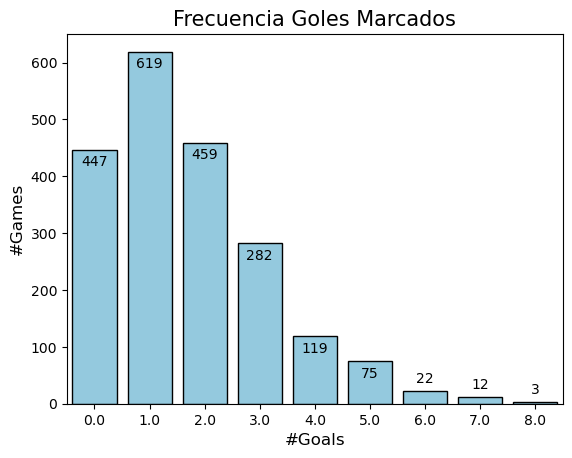

In [14]:
# Usamos countplot en lugar de histplot para datos discretos
# Esto asegura que cada columna esté alineada exactamente con el número de goles
ax = sns.countplot(data=df_train, x='Goals_team', color='skyblue', edgecolor='black')

# Añadir etiquetas de cantidad sobre cada barra para mayor claridad
for p in ax.patches:
    if p.get_x() < 5 :
        ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, -9), 
                textcoords='offset points')
    else :
        ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')
    
plt.title('Frecuencia Goles Marcados', fontsize=15)
plt.xlabel('#Goals', fontsize=12)
plt.ylabel('#Games', fontsize=12)
plt.savefig('../imgs/goals.png')

Validación gráfica otras variables

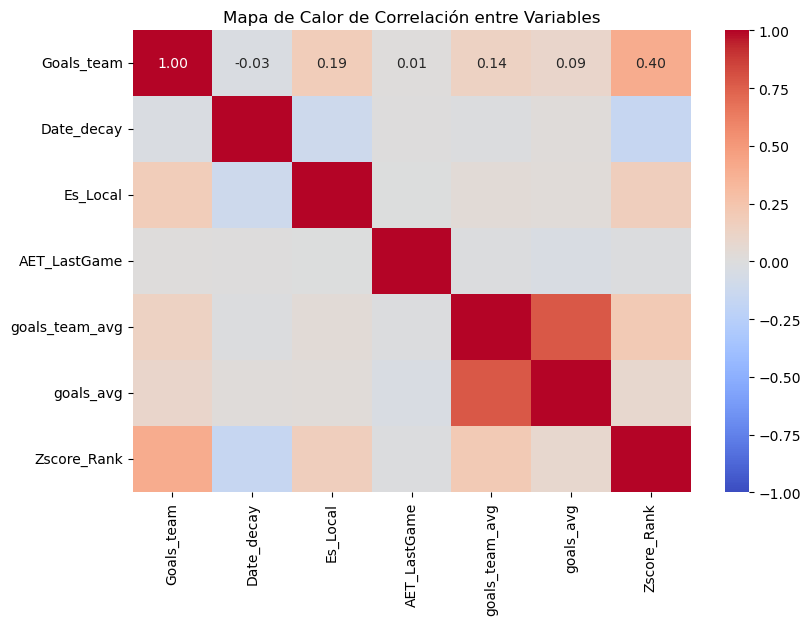

In [15]:
vars = ['Goals_team', 'Date_decay', 'Es_Local', 'AET_LastGame', 'goals_team_avg', 'goals_avg', 'Zscore_Rank']
# Calculamos la matriz de correlación
correlacion = df_train[vars].corr()

# Creamos el mapa de calor
plt.figure(figsize=(9, 6))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Mapa de Calor de Correlación entre Variables')
plt.savefig('../imgs/corr.png')

Modelación / Cantidad de goles ~ Modelo GLM Poisson

                 Generalized Linear Model Regression Results                  
Dep. Variable:             Goals_team   No. Observations:                 2038
Model:                            GLM   Df Residuals:                     2026
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3215.2
Date:               mié, 24 jun. 2026   Deviance:                       2361.3
Time:                        10:15:46   Pearson chi2:                 2.07e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2141
Covariance Type:            nonrobust                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

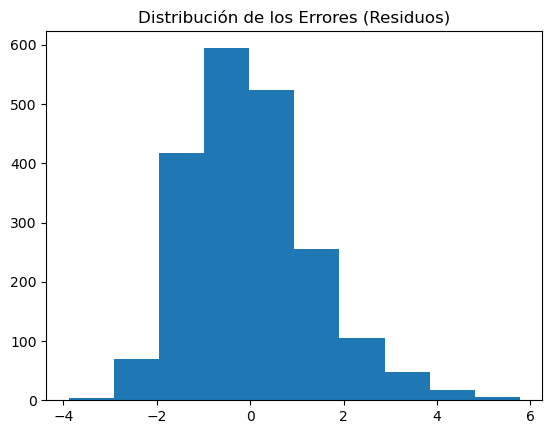

In [16]:
formula = "Goals_team ~ Date_decay + C(Game_type) + Zscore_Rank + Es_Local + goals_team_avg + goals_avg + AET_LastGame"

# Ajuste del modelo
model_1 = smf.glm(formula=formula, data=df_train, family=sm.families.Poisson()).fit()
                #var_weights=df_final['Peso_Partido']).fit()

df_model_1 = df_train.copy()
df_model_1['Prediccion'] = model_1.predict(df_model_1)
df_model_1['Error'] = df_model_1['Goals_team'] - df_model_1['Prediccion']

print(model_1.summary())
print("******* AIC:",model_1.aic,"*******")
# Visualizar si el error está centrado en 0
import matplotlib.pyplot as plt
plt.hist(df_model_1['Error'], bins=10)
plt.title("Distribución de los Errores (Residuos)")
plt.show()

Modelo sin variables Redundantes

                 Generalized Linear Model Regression Results                  
Dep. Variable:             Goals_team   No. Observations:                 2038
Model:                            GLM   Df Residuals:                     2034
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3240.6
Date:               mié, 24 jun. 2026   Deviance:                       2412.1
Time:                        10:16:00   Pearson chi2:                 2.12e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1943
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.3499      0.042      8.

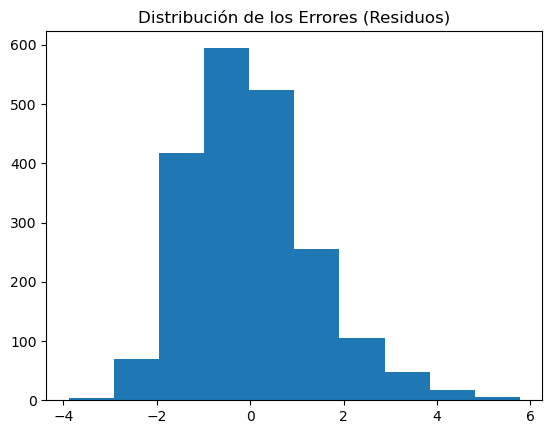

In [17]:
formula = "Goals_team ~ Date_decay + Zscore_Rank + goals_team_avg"

# Ajuste del modelo
model_2 = smf.glm(formula=formula, data=df_train, family=sm.families.Poisson()).fit()
                #var_weights=df_final['Peso_Partido']).fit()

df_model_2 = df_train.copy()
df_model_2['Prediccion'] = model_1.predict(df_model_2)
df_model_2['Error'] = df_model_2['Goals_team'] - df_model_2['Prediccion']

print(model_2.summary())
print("******* AIC:",model_2.aic,"*******")
# Visualizar si el error está centrado en 0
import matplotlib.pyplot as plt
plt.hist(df_model_2['Error'], bins=10)
plt.title("Distribución de los Errores (Residuos)")
plt.show()

Modelo con ponderador según torneo

                 Generalized Linear Model Regression Results                  
Dep. Variable:             Goals_team   No. Observations:                 2038
Model:                            GLM   Df Residuals:                     2034
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1719.4
Date:               mié, 24 jun. 2026   Deviance:                       1276.6
Time:                        10:16:42   Pearson chi2:                 1.12e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1106
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.3503      0.057      6.

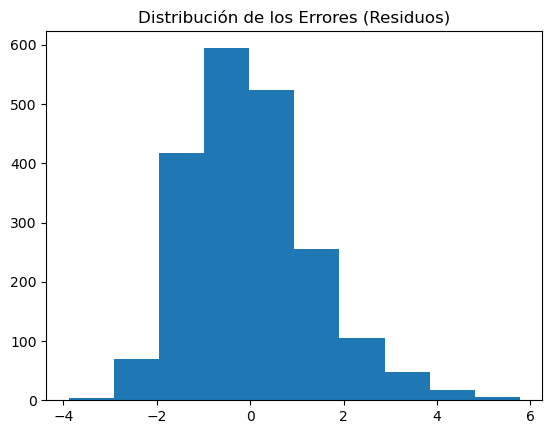

In [19]:
formula = "Goals_team ~ Date_decay + Zscore_Rank + goals_team_avg"

# Ajuste del modelo
model_3 = smf.glm(formula=formula, data=df_train, family=sm.families.Poisson(),
                var_weights=df_train['Weight']).fit()

df_model_3 = df_train.copy()
df_model_3['Prediccion'] = model_1.predict(df_model_2)
df_model_3['Error'] = df_model_3['Goals_team'] - df_model_3['Prediccion']

print(model_3.summary())
print("******* AIC:",model_3.aic,"*******")
# Visualizar si el error está centrado en 0
import matplotlib.pyplot as plt
plt.hist(df_model_3['Error'], bins=10)
plt.title("Distribución de los Errores (Residuos)")
plt.show()

Comparacion entre modelos

Para ello usamos el críterio de Akaike

In [20]:
print(f"M1: {model_1.aic}")
print(f"M2: {model_2.aic}")
print(f"M3: {model_3.aic}")

M1: 6454.323725151446
M2: 6489.16438373066
M3: 3446.7302758972487


El modelo es aquel con menos críterio de Akaike, es decir, el modelo con ponderador por tipo de Torneo

In [21]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(df_model_3['Goals_team'], df_model_3['Prediccion'])
print(f"Error promedio: {mae:.2f} goles por partido")

Error promedio: 1.04 goles por partido


In [22]:
# Identificar partidos donde el error es mayor a 2 goles
df_model_3['Abs_Error'] = abs(df_model_3['Error'])
fallos_graves = df_model_3.sort_values(by='Abs_Error', ascending=False).head(10)
print(fallos_graves[['Date', 'Team', 'Opponent', 'Goals_team', 'Prediccion','Ranking_diff']])

           Date Team     Opponent  Goals_team  Prediccion  Ranking_diff
256  2024-11-15  NZL      Vanuatu         8.0    2.228097    287.510892
597  2023-11-16  QAT  Afghanistan         8.0    2.703868    470.744174
1238 2025-11-13  CUW      Bermuda         7.0    1.817102    311.942393
257  2024-11-18  NZL        Samoa         8.0    2.881796    413.633591
820  2026-03-27  ALG    Guatemala         7.0    1.953436    320.493849
1480 2024-06-07  CZE        Malta         7.0    2.426376    488.692501
1941 2025-06-17  CAN     Honduras         6.0    1.469203    193.163121
1705 2023-09-08  ESP      Georgia         7.0    2.483051    500.771984
1368 2024-03-26  AUT       Turkey         6.0    1.500021     33.389825
703  2024-06-06  KOR    Singapore         7.0    2.508806    533.799361


Gráfico de Ranking_diff

c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


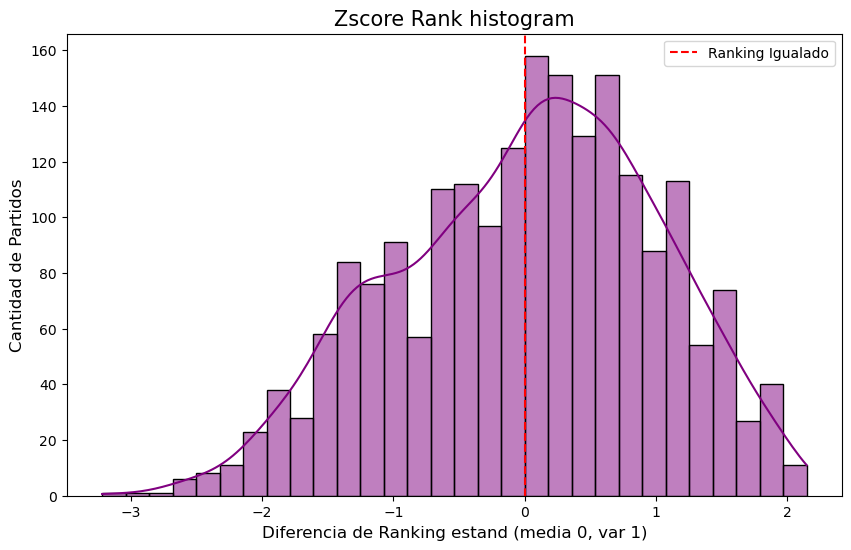

In [23]:
plt.figure(figsize=(10, 6))

# Histograma con KDE para ver la distribución
sns.histplot(df_train['Zscore_Rank'], kde=True, bins=30, color='purple', edgecolor='black')

# Línea vertical en 0 (Equipos de igual ranking)
plt.axvline(0, color='red', linestyle='--', label='Ranking Igualado')

plt.title('Zscore Rank histogram', fontsize=15)
plt.xlabel('Diferencia de Ranking estand (media 0, var 1)', fontsize=12)
plt.ylabel('Cantidad de Partidos', fontsize=12)
plt.legend()
plt.savefig('../imgs/Zscore_dist.png')

Predicción próximos partidos

In [24]:
df_goals_upd = df_train.sort_values(['Team', 'Date']).groupby('Team').tail(last_games)
df_goals_upd['total_goals'] = df_goals_upd['Goals_team'] + df_goals_upd['Goals_opponent']
metricas_recientes = df_goals_upd.groupby('Team').agg({'Goals_team': 'mean','total_goals': 'mean'}).rename(
    columns={'total_goals':'goals_avg', 'Goals_team':'goals_team_avg'})
metricas_recientes.sample(3)

df_test = df_test.drop(columns = ['goals_team_avg', 'goals_avg']).merge(metricas_recientes, on='Team', how='left')

In [25]:
df_test['Model_predict'] = model_3.predict(df_test)
df_test['Goles_Estimados'] = df_test['Model_predict'].round(0).astype(int)

In [26]:
filtro = df_test['Date'].dt.date == pd.Timestamp('2026-06-24').date()
df_hoy = df_test[filtro]
print(df_hoy[['Team', 'Opponent', 'Goles_Estimados','Model_predict']])

   Team                Opponent  Goles_Estimados  Model_predict
5   BIH                   Qatar                1       1.195476
6   BRA                Scotland                2       2.163558
7   CAN             Switzerland                1       1.223505
14  CZE                  Mexico                1       0.945257
22  HAI                 Morocco                1       0.611035
27  KOR            South Africa                2       1.792768
29  MAR                   Haiti                3       2.923335
30  MEX          Czech Republic                2       2.054571
37  QAT  Bosnia and Herzegovina                1       1.403329
38  RSA             South Korea                1       0.986007
39  SCO                  Brazil                1       0.935979
41  SUI                  Canada                2       1.587323


Guardar pronóstico

In [27]:
df_test.to_parquet('../database/predictions_r3.parquet')